In [1]:
import warnings
import os
# suppress warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
# =============================================================================
# LIBRARIES
# =============================================================================

# standart ML libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# classification
from sklearn.metrics import classification_report, confusion_matrix, f1_score
# to solve problem with unbalanced classes
from sklearn.utils.class_weight import compute_class_weight 

# tensorflow
import tensorflow as tf
import keras
from keras import layers

# additional libraries
from PIL import Image
from collections import Counter
import os, math, random, itertools, glob, shutil
import json
from pathlib import Path
from IPython.display import HTML, display

# tensorboard
from keras.callbacks import TensorBoard

2025-10-12 16:34:54.778127: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-12 16:34:54.778206: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-12 16:34:54.779352: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# =============================================================================
# CONSTANTS
# =============================================================================

# data paths
DATA_DIR = Path("../../data")
TRAIN_DATA_DIR = Path("../../data/train")
VALIDATION_DATA_DIR = Path("../../data/validation")
TEST_DATA_DIR = Path("../../data/test")

# models, runs, checkpoints paths
MODELS_DIR = Path("../../models")
RUNS_DIR = Path("../../runs")
REPORTS_DIR = Path("../../reports")
SUMMARY_CSV = REPORTS_DIR / "models_summary.csv"

# check only pictures
ALLOWED_EXTS = (".png", ".jpg", ".jpeg", ".bmp")

# data parameters
NUM_CLASSES = 4

METRIC_NAME = "sparse_categorical_accuracy"  # For integer labels
VAL_METRIC_NAME = f"val_{METRIC_NAME}"

In [4]:
# =============================================================================
# RANDOM SEED
# =============================================================================

# fixed random seed for reproducibility
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [5]:
# =============================================================================
# UTILITY DATA VISUALISATION
# =============================================================================

def _to_py(x):
    """
    numpy scalars -> python types; leave others as-is.
    """
    return x.item() if isinstance(x, np.generic) else x

def print_dict_table(
    data: dict,
    title: str | None = None,
    show_percent: bool = True,
    key_header: str = "Class",
    val_header: str = "Count",
    pct_header: str = "Percent",
    percent_decimals: int = 1,
    value_decimals: int = 3,
):
    """
    Pretty-print a dict as a text table with optional percent column.

    Example:
        counts = {"happy": 3976, "neutral": 3978, "sad": 3982, "surprise": 3173}
        print_dict_table(counts, title="Train set", show_percent=True)
        
        weights = {"happy": 0.95, "neutral": 1.2, "sad": 0.88, "surprise": 1.15}
        print_dict_table(weights, title="Class weights", show_percent=False)
    """
    # normalize & basic checks
    keys = list(data.keys())
    vals = [ _to_py(data[k]) for k in keys ]
    try:
        nums = [ float(v) for v in vals ]
    except Exception as e:
        raise ValueError("All values must be numeric to print this table.") from e

    total = sum(nums)
    # formatting helpers
    def fmt_count(x):
        if x == int(x):
            return f"{int(x):,}"
        else:
            return f"{x:,.{value_decimals}f}"

    def fmt_percent(x):
        return f"{x:.{percent_decimals}f}%"

    # column widths
    key_w = max(len(key_header), *(len(str(k)) for k in keys))
    val_w = max(len(val_header), *(len(fmt_count(v)) for v in nums))
    pct_w = max(len(pct_header), len(f"{0:.{percent_decimals}f}%"))

    if title:
        print(title)

    # header
    if show_percent and total > 0:
        print(f"{key_header:<{key_w}}  {val_header:>{val_w}}  {pct_header:>{pct_w}}")
        print(f"{'-'*key_w}  {'-'*val_w}  {'-'*pct_w}")
    else:
        print(f"{key_header:<{key_w}}  {val_header:>{val_w}}")
        print(f"{'-'*key_w}  {'-'*val_w}")

    # rows
    for k, v in zip(keys, nums):
        if show_percent and total > 0:
            pct = 100.0 * v / total
            print(f"{k:<{key_w}}  {fmt_count(v):>{val_w}}  {fmt_percent(pct):>{pct_w}}")
        else:
            print(f"{k:<{key_w}}  {fmt_count(v):>{val_w}}")

    # footer (total)
    if show_percent and total > 0:
        print(f"{'-'*key_w}  {'-'*val_w}  {'-'*pct_w}")
        print(f"{'TOTAL':<{key_w}}  {fmt_count(total):>{val_w}}  {fmt_percent(100.0):>{pct_w}}")
    else:
        print(f"{'-'*key_w}  {'-'*val_w}")
        print(f"{'TOTAL':<{key_w}}  {fmt_count(total):>{val_w}}")

# ---------- Dataframe HTML-style visualisation ----------
def display_df(df, rows = 10, show_index = False):
    """
    Display a DataFrame in HTML format.
    Args:
        df: DataFrame to display
        rows: Number of rows to display
        show_index: Whether to show row indices
    """
    if rows==0:
        display(HTML(df.to_html(index=show_index)))
    else:
        display(HTML(df.head(rows).to_html(index=show_index)))

In [6]:
# =============================================================================
# DATA-LOADERS
# =============================================================================

from keras.utils import image_dataset_from_directory

def make_generators(train_dir, val_dir, test_dir, img_size=(48,48),
                    color_mode="grayscale", batch_size=64, augment=True):
    
    # Define preprocessing function
    def preprocess_image(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label
    
    # Define augmentation function (fixed for TensorFlow compatibility)
    def augment_image(image, label):
        if augment:
            # Horizontal flip
            image = tf.image.random_flip_left_right(image)
            
            # Random brightness
            image = tf.image.random_brightness(image, 0.2)
            
            # Random contrast
            image = tf.image.random_contrast(image, 0.8, 1.2)

            image = tf.keras.preprocessing.image.apply_affine_transform(
                image.numpy(), 
                shear=0.3,
                fill_mode='nearest'
            )            
            
            # Random rotation using tf.keras preprocessing
            # Note: rotation is applied differently in tf 2.x
            # We'll use a simple approach with limited rotation
            angle = tf.random.uniform([], -0.1, 0.1)  # radians
            image = tf.keras.preprocessing.image.apply_affine_transform(
                image.numpy(), theta=angle * 180 / 3.14159, 
                channel_axis=2, fill_mode='nearest'
            ) if hasattr(tf.keras.preprocessing.image, 'apply_affine_transform') else image
            
        return image, label
    
    # Alternative augmentation without rotation (more stable)
    def augment_image_simple(image, label):
        # Horizontal flip
        image = tf.image.random_flip_left_right(image)
        
        # Random brightness
        image = tf.image.random_brightness(image, 0.2)
        
        # Random contrast
        image = tf.image.random_contrast(image, 0.8, 1.2)
        
        # Clip to valid range
        image = tf.clip_by_value(image, 0.0, 1.0)
        
        return image, label
    
    print("-"*50)
    print("Train data:")
    train_ds = image_dataset_from_directory(
        train_dir,
        class_names=CLASS_ORDER,  # FIXED ORDER for reproducibility!
        image_size=img_size,
        batch_size=batch_size,
        color_mode=color_mode,
        shuffle=True
    )
    train_ds = train_ds.map(preprocess_image)
    if augment:
        train_ds = train_ds.map(augment_image_simple)  # Using simple augmentation
    
    print("Validation data:")
    val_ds = image_dataset_from_directory(
        val_dir,
        class_names=CLASS_ORDER,  # FIXED ORDER for reproducibility!
        image_size=img_size,
        batch_size=batch_size,
        color_mode=color_mode,
        shuffle=False
    )
    val_ds = val_ds.map(preprocess_image)
    
    print("Test data:")
    test_ds = image_dataset_from_directory(
        test_dir,
        class_names=CLASS_ORDER,  # FIXED ORDER for reproducibility!
        image_size=img_size,
        batch_size=batch_size,
        color_mode=color_mode,
        shuffle=False
    )
    test_ds = test_ds.map(preprocess_image)
    
    return train_ds, val_ds, test_ds

In [7]:
# =============================================================================
# FIXED CLASS ORDER AND WEIGHTS - EXPERIMENT REPRODUCIBILITY
# =============================================================================

# CRITICAL: Use the SAME class order as in the main notebook
# This ensures reproducible experiments and correct class weight mapping
CLASS_ORDER = ['happy', 'neutral', 'sad', 'surprise']

# Use the SAME pre-computed class weights as in the main notebook
CLASS_WEIGHTS = {
    0: 0.950,  # happy
    1: 0.950,  # neutral  
    2: 0.949,  # sad
    3: 1.190   # surprise
}

print("=" * 70)
print("FIXED CLASS ORDER AND WEIGHTS - MATCHING MAIN NOTEBOOK")
print("=" * 70)
print(f"Class order: {CLASS_ORDER}")
print("Class weights:")
for i, cls in enumerate(CLASS_ORDER):
    print(f"  {i}: {cls} = {CLASS_WEIGHTS[i]:.3f}")
print("=" * 70)

# Set CLASS_LABELS to match the fixed order
CLASS_LABELS = CLASS_ORDER

FIXED CLASS ORDER AND WEIGHTS - MATCHING MAIN NOTEBOOK
Class order: ['happy', 'neutral', 'sad', 'surprise']
Class weights:
  0: happy = 0.950
  1: neutral = 0.950
  2: sad = 0.949
  3: surprise = 1.190


In [8]:
# =============================================================================
# EVALUATION AND VISUALIZATION MODULE
# =============================================================================

def save_metrics(metrics: dict, out_json: Path):
    """
    Save any metrics/parameters to JSON file in readable format.
    """
    with open(out_json, "w") as f:
        json.dump(metrics, f, indent=2)

def save_history(history, out_csv: Path):
    """
    Save Keras training history to CSV file.
    """
    df = pd.DataFrame(history.history)
    df.to_csv(out_csv, index=False)

def make_run_dir(name: str) -> Path:
    """
    Create a unique directory for an experiment and return the path.
    """
    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = RUNS_DIR / f"{ts}_{name}"
    (run_dir / "figs").mkdir(parents=True, exist_ok=True)
    (run_dir / "tb").mkdir(parents=True, exist_ok=True)
    return run_dir

def append_summary_row(row: dict):
    """
    Append a row to the general CSV summary of models.
    """
    df_new = pd.DataFrame([row])
    if SUMMARY_CSV.exists():
        df = pd.read_csv(SUMMARY_CSV)
        df = pd.concat([df, df_new], ignore_index=True)
    else:
        df = df_new
    df.to_csv(SUMMARY_CSV, index=False)

class ModelEvaluator:
    """
    Unified class for model evaluation, visualization, and artifact saving.
    Designed for modern tf.data.Dataset API.
    """
    
    def __init__(self, class_labels=None):
        """
        Initialize evaluator with class labels.
        
        Args:
            class_labels: List of class names (e.g., ['happy', 'sad', 'neutral', 'surprise'])
        """
        self.class_labels = class_labels or ['happy', 'sad', 'neutral', 'surprise']
    
    def get_predictions(self, model, test_dataset):
        """
        Get predictions from model on test dataset.
        
        Args:
            model: Trained Keras model
            test_dataset: tf.data.Dataset test data
            
        Returns:
            tuple: (y_true, y_pred, y_prob)
        """
        # Get predictions
        y_prob = model.predict(test_dataset, verbose=0)
        y_pred = y_prob.argmax(axis=1)
        
        # Get true labels from dataset
        y_true = []
        for batch in test_dataset.take(-1):
            _, labels_batch = batch
            y_true.extend(labels_batch.numpy())
        y_true = np.array(y_true)
        
        return y_true, y_pred, y_prob
    
    def compute_metrics(self, y_true, y_pred):
        """
        Compute comprehensive evaluation metrics.
        
        Args:
            y_true: True labels
            y_pred: Predicted labels
            
        Returns:
            dict: Dictionary of metrics
        """
        from sklearn.metrics import accuracy_score, f1_score, classification_report
        
        acc = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        weighted_f1 = f1_score(y_true, y_pred, average="weighted")
        
        # Detailed classification report
        report = classification_report(
            y_true, y_pred, 
            target_names=self.class_labels, 
            digits=3, 
            output_dict=True
        )
        
        return {
            "accuracy": acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "classification_report": report
        }
    
    def plot_confusion_matrix(self, y_true, y_pred, save_path=None, 
                            normalize=True, title="Confusion Matrix"):
        """
        Plot and optionally save confusion matrix.
        
        Args:
            y_true: True labels
            y_pred: Predicted labels
            save_path: Path to save plot (optional)
            normalize: Whether to normalize the matrix
            title: Plot title
        """
        from sklearn.metrics import confusion_matrix
        
        cm = confusion_matrix(y_true, y_pred)
        
        if normalize:
            cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)
        
        plt.figure(figsize=(8, 6))
        im = plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
        plt.colorbar(im, fraction=0.046, pad=0.04)
        
        tick_marks = np.arange(len(self.class_labels))
        plt.xticks(tick_marks, self.class_labels, rotation=45, ha="right")
        plt.yticks(tick_marks, self.class_labels)
        
        # Add text annotations
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            txt = f"{cm[i, j]:.2f}" if normalize else f"{int(cm[i, j])}"
            plt.text(j, i, txt, horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black", fontsize=10)
        
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(title)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        
        plt.show()
    
    def plot_training_history(self, history, save_path=None, title_suffix=""):
        """
        Plot training history (loss and accuracy curves).
        
        Args:
            history: Keras History object
            save_path: Path to save plot (optional)
            title_suffix: Suffix for plot titles
        """
        h = history.history
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Accuracy plot
        axes[0].plot(h["accuracy"], label="train", linewidth=2)
        axes[0].plot(h["val_accuracy"], label="validation", linewidth=2)
        axes[0].set_title(f"Accuracy{title_suffix}")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Accuracy")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Loss plot
        axes[1].plot(h["loss"], label="train", linewidth=2)
        axes[1].plot(h["val_loss"], label="validation", linewidth=2)
        axes[1].set_title(f"Loss{title_suffix}")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Loss")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        
        plt.show()
    
    def evaluate_and_save(self, model, test_dataset, output_dir, model_name="model"):
        """
        Complete evaluation pipeline: compute metrics, create plots, save artifacts.
        
        Args:
            model: Trained Keras model
            test_dataset: tf.data.Dataset test data
            output_dir: Directory to save artifacts
            model_name: Name for saved files
            
        Returns:
            dict: Evaluation metrics
        """
        
        # Get predictions
        y_true, y_pred, y_prob = self.get_predictions(model, test_dataset)
        
        # Compute metrics
        metrics = self.compute_metrics(y_true, y_pred)
        
        # Save classification report
        report_text = classification_report(
            y_true, y_pred, 
            target_names=self.class_labels, 
            digits=3
        )
        
        with open(output_dir / f"{model_name}_classification_report.txt", "w") as f:
            f.write(report_text)
        
        # Save confusion matrix plot
        self.plot_confusion_matrix(
            y_true, y_pred, 
            save_path=output_dir / f"{model_name}_confusion_matrix.png",
            title=f"Confusion Matrix - {model_name}"
        )
        
        # Save metrics to JSON
        save_metrics(metrics, output_dir / f"{model_name}_metrics.json")
        
        return metrics
    
    def print_summary(self, y_true, y_pred, metrics):
        """
        Print evaluation summary to console.
        
        Args:
            y_true: True labels
            y_pred: Predicted labels
            metrics: Dictionary of computed metrics
        """
        print("=" * 60)
        print("EVALUATION SUMMARY")
        print("=" * 60)
        print(f"Accuracy: {metrics['accuracy']:.3f}")
        print(f"Macro F1: {metrics['macro_f1']:.3f}")
        print(f"Weighted F1: {metrics['weighted_f1']:.3f}")
        print("\nDetailed Classification Report:")
        print(classification_report(y_true, y_pred, target_names=self.class_labels, digits=3))
        print("=" * 60)

In [9]:
# =============================================================================
# MODEL SUMMARY FUNCTIONS
# =============================================================================

def create_model_summary(model, history, test_metrics, model_name="model", training_time=None):
    """
    Create comprehensive model summary for comparison.
    
    Args:
        model: Trained Keras model
        history: Training history
        test_metrics: Test evaluation metrics
        model_name: Name of the model
        
    Returns:
        dict: Summary row for comparison table
    """
    h = history.history
    
    summary = {
        "Model": model_name,
        "Parameters": int(model.count_params()),
        
        # Training metrics
        "Train_Acc_Final": float(h[METRIC_NAME][-1]),
        "Train_Loss_Final": float(h["loss"][-1]),
        
        # Validation metrics
        "Val_Acc_Best": float(np.max(h[VAL_METRIC_NAME])),
        "Val_Acc_Final": float(h[VAL_METRIC_NAME][-1]),
        "Val_Loss_Min": float(np.min(h["val_loss"])),
        "Val_Loss_Final": float(h["val_loss"][-1]),
        
        # Epochs
        "Total_Epochs": int(len(h["loss"])),
        "Best_Epoch": int(np.argmin(h["val_loss"]) + 1),
        
        # Test metrics
        "Test_Accuracy": float(test_metrics["accuracy"]),
        "Test_Macro_F1": float(test_metrics["macro_f1"]),
        "Test_Weighted_F1": float(test_metrics["weighted_f1"]),
        
        # Analysis
        "Overfitting": float(h[VAL_METRIC_NAME][-1]) < float(np.max(h[VAL_METRIC_NAME])) - 0.05,
        "Train_Val_Gap": float(h[METRIC_NAME][-1] - h[VAL_METRIC_NAME][-1]),
        "Generalization_Gap": float(h[VAL_METRIC_NAME][-1] - test_metrics["accuracy"]),
    }
    
    # Add timing if provided
    if training_time is not None:
        summary["Training_Time_Minutes"] = float(training_time / 60)
        summary["Training_Time_Hours"] = float(training_time / 3600)
        summary["Avg_Time_Per_Epoch_Sec"] = float(training_time / len(h["loss"]))
        summary["Efficiency_Score"] = float(test_metrics["accuracy"] / (training_time / 60))  # Accuracy per minute
    
    return summary


In [10]:
# =============================================================================
# CNN CONSTRUCTOR
# =============================================================================

def build_cnn(
    input_shape=(48, 48, 1),
    num_classes=4,
    channels=(32, 64, 128),    # (filters) per stage
    convs_per_block=2,         # conv -> BN -> act
    dropout_head=0.0,
    activation="leakyrelu",    # "relu" | "leakyrelu"
    lr=0.001,
    l2_reg=0.0001,
    use_batch_norm=True,       # Enable/disable batch normalization
    pool_size=2,              # MaxPooling pool size
    kernel_size=3,            # Conv2D kernel size
    padding="same"            # Conv2D padding
):
    """
    Build a CNN model for emotion recognition.
    
    Args:
        input_shape: Input image shape (height, width, channels)
        num_classes: Number of output classes
        channels: Tuple of filter numbers for each stage
        convs_per_block: Number of conv layers per block
        dropout_head: Dropout rate in the head (0.0 to disable)
        activation: Activation function ("relu" or "leakyrelu")
        lr: Learning rate for Adam optimizer
        l2_reg: L2 regularization strength (0.0 to disable)
        use_batch_norm: Whether to use batch normalization
        pool_size: MaxPooling pool size
        kernel_size: Conv2D kernel size
        padding: Conv2D padding type
        
    Returns:
        keras.Model: Compiled CNN model
    """
    # Activation function factory
    if activation == "leakyrelu":
        Act = lambda: layers.LeakyReLU(0.1)
    elif activation == "relu":
        Act = lambda: layers.ReLU()
    else:
        raise ValueError(f"Unsupported activation: {activation}. Use 'relu' or 'leakyrelu'")
    
    # Regularization
    reg = keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
    
    # Input layer
    x_in = keras.Input(shape=input_shape, name="input")
    x = x_in
    
    # Convolutional blocks
    for i, num_filters in enumerate(channels):
        for j in range(convs_per_block):
            x = layers.Conv2D(
                num_filters, 
                kernel_size, 
                padding=padding,
                kernel_initializer="he_normal",
                kernel_regularizer=reg,
                name=f"conv_{i+1}_{j+1}"
            )(x)
            
            if use_batch_norm:
                x = layers.BatchNormalization(name=f"bn_{i+1}_{j+1}")(x)
            
            x = Act()(x)
        
        # MaxPooling after each block (except the last one)
        if i < len(channels) - 1:
            x = layers.MaxPool2D(pool_size, name=f"pool_{i+1}")(x)
    
    # Global average pooling
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    
    # Dropout in head
    if dropout_head > 0:
        x = layers.Dropout(dropout_head, name="dropout_head")(x)
    
    # Output layer
    out = layers.Dense(
        num_classes, 
        activation="softmax", 
        name="output",
        kernel_regularizer=reg
    )(x)
    
    # Create and compile model
    model = keras.Model(x_in, out, name="emotion_cnn")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[METRIC_NAME]
    )
    
    return model

In [11]:
# =============================================================================
# TRAINING PIPELINE FUNCTIONS
# =============================================================================

def train_model(model, train_dataset, val_dataset, model_name, run_dir, 
                class_labels, epochs=20, callbacks=None, class_weights=None):
    """
    Train model only (without evaluation).
    
    Args:
        model: Compiled Keras model
        train_dataset: Training dataset
        val_dataset: Validation dataset
        model_name: Name for the model
        run_dir: Directory to save artifacts
        class_labels: List of class names
        epochs: Number of training epochs
        callbacks: List of Keras callbacks
        class_weights: Dictionary of class weights
        
    Returns:
        tuple: (trained_model, history)
    """
    print(f"Starting training for {model_name}...")

    # Start timer
    train_start_time = time.time()
    train_start_str = time.strftime("%Y-%m-%d %H:%M:%S")
    print(f"Training started at: {train_start_str}")    
    
    # Train model
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=callbacks or [],
        class_weight=class_weights,
        verbose=1
    )

    # End timer
    train_end_time = time.time()
    train_duration = train_end_time - train_start_time
    train_end_str = time.strftime("%Y-%m-%d %H:%M:%S")

    # Print training time
    print(f"\n{'='*70}")
    print(f"TRAINING TIME - {model_name.upper()}")
    print(f"{'='*70}")
    print(f"Started: {train_start_str}")
    print(f"Ended: {train_end_str}")
    print(f"Duration: {train_duration:.2f} seconds ({train_duration/60:.2f} minutes)")
    print(f"Average time per epoch: {train_duration/len(history.history['loss']):.2f} seconds")
    print(f"{'='*70}")    
    
    # Save model
    model.save(run_dir / f"{model_name}.keras")
    
    # Save training history
    save_history(history, run_dir / "training_history.csv")
    
    # Save model summary
    with open(run_dir / "model_summary.txt", "w", encoding="utf-8") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))
    
    # Save training parameters
    training_params = {
        "model_name": model_name,
        "total_epochs": int(len(history.history["loss"])),
        "final_train_loss": float(history.history["loss"][-1]),
        "final_val_loss": float(history.history["val_loss"][-1]),
        "final_train_acc": float(history.history[METRIC_NAME][-1]),
        "final_val_acc": float(history.history[VAL_METRIC_NAME][-1]),
        "best_val_acc": float(max(history.history[VAL_METRIC_NAME])),
        "best_epoch": int(np.argmax(history.history[VAL_METRIC_NAME]) + 1),
        "training_time_seconds": float(train_duration),
        "training_time_minutes": float(train_duration / 60),
        "avg_time_per_epoch": float(train_duration / len(history.history["loss"])),
        "training_started": train_start_str,
        "training_ended": train_end_str
    }
    save_metrics(training_params, run_dir / "training_params.json")
    
    return model, history, train_duration

def evaluate_model(model, test_dataset, model_name, run_dir, class_labels):
    """
    Evaluate model only (without training).
    
    Args:
        model: Trained Keras model
        test_dataset: Test dataset
        model_name: Name for the model
        run_dir: Directory to save artifacts
        class_labels: List of class names
        
    Returns:
        dict: Test evaluation metrics
    """
    print(f"Starting evaluation for {model_name}...")
    
    # Evaluate model
    evaluator = ModelEvaluator(class_labels)
    test_metrics = evaluator.evaluate_and_save(
        model=model,
        test_dataset=test_dataset,
        output_dir=run_dir,
        model_name=model_name
    )
    
    return test_metrics

def train_and_evaluate_model(model, train_dataset, val_dataset, test_dataset, 
                           model_name, run_dir, class_labels, epochs=20, 
                           callbacks=None, class_weights=None):
    """
    Complete training and evaluation pipeline.
    
    Args:
        model: Compiled Keras model
        train_dataset: Training dataset
        val_dataset: Validation dataset
        test_dataset: Test dataset
        model_name: Name for the model
        run_dir: Directory to save artifacts
        class_labels: List of class names
        epochs: Number of training epochs
        callbacks: List of Keras callbacks
        class_weights: Dictionary of class weights
        
    Returns:
        tuple: (trained_model, history, test_metrics)
    """
    # Train model
    model, history = train_model(
        model, train_dataset, val_dataset, model_name, run_dir, 
        class_labels, epochs, callbacks, class_weights
    )
    
    # Evaluate model
    test_metrics = evaluate_model(model, test_dataset, model_name, run_dir, class_labels)
    
    return model, history, test_metrics

def print_training_summary(history, model_name):
    """
    Print training results summary.
    
    Args:
        history: Keras History object
        model_name: Name of the model
    """
    h = history.history
    best_epoch = np.argmax(h[VAL_METRIC_NAME]) + 1
    
    print("\n" + "="*70)
    print(f"TRAINING RESULTS - {model_name.upper()}")
    print("="*70)
    print(f"Total epochs: {len(h['loss'])}")
    print(f"Best epoch: {best_epoch}")
    print(f"Final training accuracy: {h[METRIC_NAME][-1]:.3f}")
    print(f"Final validation accuracy: {h[VAL_METRIC_NAME][-1]:.3f}")
    print(f"Best validation accuracy: {max(h[VAL_METRIC_NAME]):.3f}")
    print(f"Final training loss: {h['loss'][-1]:.3f}")
    print(f"Final validation loss: {h['val_loss'][-1]:.3f}")
    print(f"Best validation loss: {min(h['val_loss']):.3f}")
    
    # Check for overfitting
    overfitting = h[VAL_METRIC_NAME][-1] < max(h[VAL_METRIC_NAME]) - 0.05
    print(f"Overfitting detected: {'Yes' if overfitting else 'No'}")
    print("="*70)

def print_evaluation_summary(test_metrics, model_name):
    """
    Print evaluation results summary.
    
    Args:
        test_metrics: Dictionary of test metrics
        model_name: Name of the model
    """
    print("\n" + "="*70)
    print(f"EVALUATION RESULTS - {model_name.upper()}")
    print("="*70)
    print(f"Test accuracy: {test_metrics['accuracy']:.3f}")
    print(f"Test macro F1: {test_metrics['macro_f1']:.3f}")
    print(f"Test weighted F1: {test_metrics['weighted_f1']:.3f}")
    print("="*70)
    

def plot_training_history(history, model_name="Model", save_path=None):
    """
    Plot training history (loss and accuracy curves).
    
    Args:
        history: Keras History object
        model_name: Name of the model for title
        save_path: Path to save plot (optional)
    """
    h = history.history
    epochs = range(1, len(h['loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    axes[0].plot(epochs, h[METRIC_NAME], 'b-', label='Training', linewidth=2, marker='o')
    axes[0].plot(epochs, h[VAL_METRIC_NAME], 'r-', label='Validation', linewidth=2, marker='s')
    axes[0].set_title(f'Model Accuracy - {model_name}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1)
    
    # Loss plot
    axes[1].plot(epochs, h['loss'], 'b-', label='Training', linewidth=2, marker='o')
    axes[1].plot(epochs, h['val_loss'], 'r-', label='Validation', linewidth=2, marker='s')
    axes[1].set_title(f'Model Loss - {model_name}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Training history plot saved to: {save_path}")
    
    plt.show()

In [12]:
import time
FULL_RUN_START_TIME = time.time()
FULL_RUN_START_STR = time.strftime("%Y-%m-%d %H:%M:%S")

print("=" * 100)
print("FULL TRAINING RUN STARTED")
print("=" * 100)
print(f"Start time: {FULL_RUN_START_STR}")
print(f"Random seed: {RANDOM_SEED}")
print(f"")
print("Models to train:")
print("  1. Complex Custom GS CNN (5 Blocks)")
print("  2. Complex Custom RGB CNN (5 Blocks)")
print("")
print("Estimated total time: 1-2 hours")
print("=" * 100)

FULL TRAINING RUN STARTED
Start time: 2025-10-12 16:34:56
Random seed: 42

Models to train:
  1. Complex Custom GS CNN (5 Blocks)
  2. Complex Custom RGB CNN (5 Blocks)

Estimated total time: 1-2 hours


## GS Mode

In [13]:
# =============================================================================
# DATA LOADERS FOR COMPLEX CUSTOM GS CNN (WITH AUGMENTATION)
# =============================================================================

print("=" * 70)
print("CREATING DATA LOADERS FOR COMPLEX CUSTOM GS CNN")
print("=" * 70)

# Configuration for Complex Custom GS CNN
IMG_SIZE_COMPLEX = (48, 48)
IMAGE_SHAPE_COMPLEX_GS = (*IMG_SIZE_COMPLEX, 1)
BATCH_SIZE_COMPLEX = 64
COLOR_MODE_COMPLEX = "grayscale"
AUGMENT_COMPLEX = True  # Enable augmentation for better generalization


print(f"Image size: {IMG_SIZE_COMPLEX}")
print(f"Batch size: {BATCH_SIZE_COMPLEX}")
print(f"Color mode: {COLOR_MODE_COMPLEX}")
print(f"Augmentation: {AUGMENT_COMPLEX}")

# Create data loaders for Complex Custom GS CNN
train_gen_complex_gs, val_gen_complex_gs, test_gen_complex_gs = make_generators(
    train_dir=TRAIN_DATA_DIR,
    val_dir=VALIDATION_DATA_DIR,
    test_dir=TEST_DATA_DIR,
    img_size=IMG_SIZE_COMPLEX,
    color_mode=COLOR_MODE_COMPLEX,
    batch_size=BATCH_SIZE_COMPLEX,
    augment=AUGMENT_COMPLEX
)

# Sanity check for Complex Custom GS CNN data
print("\n" + "=" * 70)
print("SANITY CHECK - COMPLEX CUSTOM GS CNN DATA")
print("=" * 70)

# Get a sample batch
for xb, yb in train_gen_complex_gs.take(1):
    break

print(f"Train batch shape: {xb.shape}")
print(f"Labels shape: {yb.shape}")
print(f"Image dtype: {xb.dtype}")
print(f"Label dtype: {yb.dtype}")
print(f"Image range: [{tf.reduce_min(xb):.3f}, {tf.reduce_max(xb):.3f}]")
print(f"Unique labels: {tf.unique(yb)[0].numpy()}")

# Check if augmentation is working
print(f"\nAugmentation enabled: {AUGMENT_COMPLEX}")
if AUGMENT_COMPLEX:
    print("✓ Data augmentation is active - images will be randomly transformed during training")
else:
    print("⚠ Data augmentation is disabled")

print("=" * 70)
print("✓ Complex Custom GS CNN data loaders created successfully")
print("=" * 70)

CREATING DATA LOADERS FOR COMPLEX CUSTOM GS CNN
Image size: (48, 48)
Batch size: 64
Color mode: grayscale
Augmentation: True
--------------------------------------------------
Train data:
Found 15109 files belonging to 4 classes.
Validation data:
Found 4977 files belonging to 4 classes.
Test data:
Found 128 files belonging to 4 classes.

SANITY CHECK - COMPLEX CUSTOM GS CNN DATA
Train batch shape: (64, 48, 48, 1)
Labels shape: (64,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>
Image range: [0.000, 0.993]
Unique labels: [0 2 3 1]

Augmentation enabled: True
✓ Data augmentation is active - images will be randomly transformed during training
✓ Complex Custom GS CNN data loaders created successfully


In [14]:
# Use the FIXED class weights defined at the beginning of the notebook
# No need to recompute - they are consistent with the fixed class order
print("Using FIXED class weights from the beginning of the notebook")
print_dict_table(CLASS_WEIGHTS, title="Class weights (FIXED)", val_header="Value", show_percent=False, value_decimals=3)    

Using FIXED class weights from the beginning of the notebook
Class weights (FIXED)
Class  Value
-----  -----
0      0.950
1      0.950
2      0.949
3      1.190
-----  -----
TOTAL  4.039


In [15]:
# =============================================================================
# COMPLEX CUSTOM GS CNN (5 BLOCKS) - "HEAVY" MODEL
# =============================================================================

print("=" * 70)
print("COMPLEX CUSTOM GS CNN - 5 BLOCKS ARCHITECTURE")
print("=" * 70)
print("✓ Returning to grayscale data for optimal performance")
print("✓ 5 convolutional blocks for maximum capacity")
print("✓ Heavy regularization to prevent overfitting")
print("=" * 70)

# Create complex GS CNN with 5 blocks
cnn_complex_gs = build_cnn(
    input_shape=IMAGE_SHAPE_COMPLEX_GS,  # (48, 48, 1) - grayscale
    num_classes=NUM_CLASSES,
    channels=(64, 128, 512, 512, 128),  
    convs_per_block=2,                   
    dropout_head=0.3,                    
    activation="leakyrelu",
    l2_reg=0.001,
    lr=0.0001                            
)

print("\n" + "=" * 70)
print("COMPLEX GS CNN MODEL SUMMARY")
print("=" * 70)
cnn_complex_gs.summary()

total_params = cnn_complex_gs.count_params()
print(f"\n" + "=" * 70)
print("COMPLEX GS CNN STATISTICS")
print("=" * 70)
print(f"Total parameters: {total_params:,}")
print(f"Model size: ~{total_params * 4 / 1024:.1f} KB")
print(f"Architecture: 5 blocks × 3 conv layers = 15 conv layers")
print("=" * 70)

COMPLEX CUSTOM GS CNN - 5 BLOCKS ARCHITECTURE
✓ Returning to grayscale data for optimal performance
✓ 5 convolutional blocks for maximum capacity
✓ Heavy regularization to prevent overfitting

COMPLEX GS CNN MODEL SUMMARY
Model: "emotion_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 48, 48, 1)]       0         
                                                                 
 conv_1_1 (Conv2D)           (None, 48, 48, 64)        640       
                                                                 
 bn_1_1 (BatchNormalization  (None, 48, 48, 64)        256       
 )                                                               
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 48, 48, 64)        0         
                                                                 
 conv_1_2 (Conv2D)           (N

COMPLEX CUSTOM GS CNN TRAINING CONFIGURATION
Maximum epochs: 50
Batch size: 64
Image size: (48, 48)
Data augmentation: True
Class weights: Enabled
Architecture: 5 blocks × 3 conv layers = 15 conv layers
Parameters: 8,677,572

PHASE 1: TRAINING COMPLEX CUSTOM GS CNN
Starting training for complex_cnn_gs...
Training started at: 2025-10-12 16:35:16
Epoch 1/50


I0000 00:00:1760286920.822835   96387 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


237/237 [==============================] - ETA: 0s - loss: 6.3157 - sparse_categorical_accuracy: 0.5195
Epoch 1: val_sparse_categorical_accuracy improved from -inf to 0.51437, saving model to ../../models/best_complex_cnn_gs.keras
237/237 [==============================] - 21s 51ms/step - loss: 6.3157 - sparse_categorical_accuracy: 0.5195 - val_loss: 6.1736 - val_sparse_categorical_accuracy: 0.5144 - lr: 1.0000e-04
Epoch 2/50
236/237 [============================>.] - ETA: 0s - loss: 5.7181 - sparse_categorical_accuracy: 0.6471
Epoch 2: val_sparse_categorical_accuracy improved from 0.51437 to 0.63211, saving model to ../../models/best_complex_cnn_gs.keras
237/237 [==============================] - 10s 40ms/step - loss: 5.7181 - sparse_categorical_accuracy: 0.6471 - val_loss: 5.6204 - val_sparse_categorical_accuracy: 0.6321 - lr: 1.0000e-04
Epoch 3/50
235/237 [============================>.] - ETA: 0s - loss: 5.2601 - sparse_categorical_accuracy: 0.7033
Epoch 3: val_sparse_categorical_a

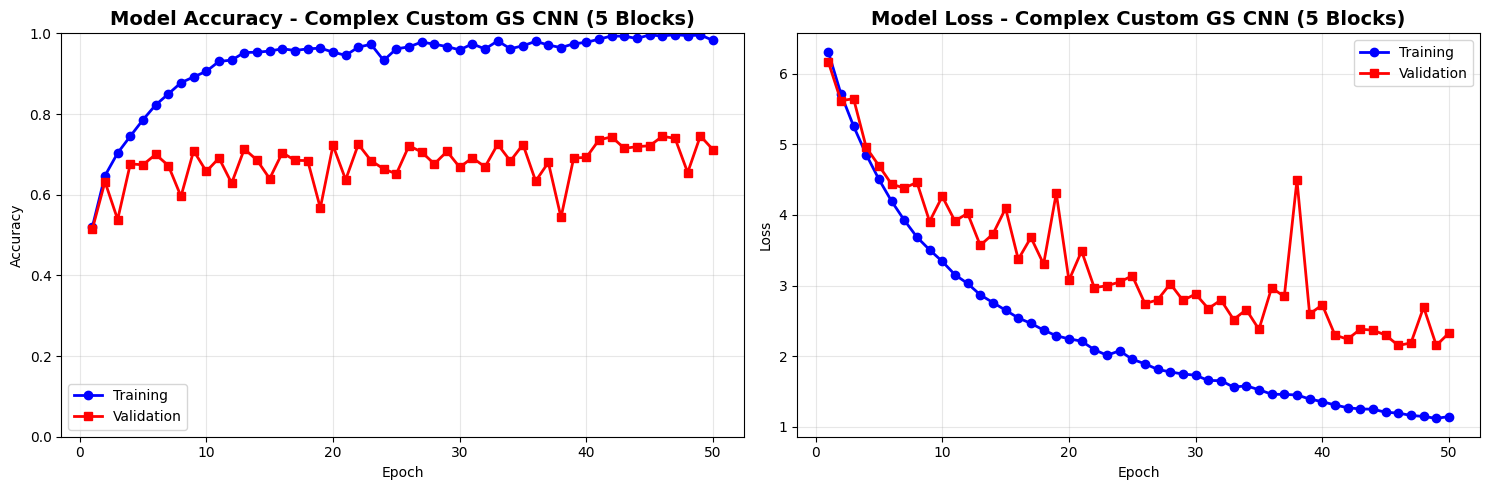

In [16]:
# =============================================================================
# COMPLEX CUSTOM GS CNN TRAINING PIPELINE
# =============================================================================

# Training configuration for Complex GS CNN
COMPLEX_EPOCHS = 50  # More epochs for complex model

# Callbacks for Complex GS CNN
callbacks_complex = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,  # More patience for complex model
        restore_best_weights=True,
        verbose=1
    ),
    
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / "best_complex_cnn_gs.keras"),
        monitor=VAL_METRIC_NAME,
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    keras.callbacks.TensorBoard(
        log_dir=RUNS_DIR / "tensorboard" / "complex_cnn_gs",
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch'
    )
]

print("=" * 70)
print("COMPLEX CUSTOM GS CNN TRAINING CONFIGURATION")
print("=" * 70)
print(f"Maximum epochs: {COMPLEX_EPOCHS}")
print(f"Batch size: {BATCH_SIZE_COMPLEX}")
print(f"Image size: {IMG_SIZE_COMPLEX}")
print(f"Data augmentation: {AUGMENT_COMPLEX}")
print(f"Class weights: Enabled")
print(f"Architecture: 5 blocks × 3 conv layers = 15 conv layers")
print(f"Parameters: {cnn_complex_gs.count_params():,}")
print("=" * 70)

# Create run directory
run_dir_complex_gs = make_run_dir("complex_cnn_5blocks_gs")

# Train Complex GS CNN model
print("\n" + "=" * 70)
print("PHASE 1: TRAINING COMPLEX CUSTOM GS CNN")
print("=" * 70)

complex_trained_gs, complex_history_gs, train_time_gs = train_model(
    model=cnn_complex_gs,
    train_dataset=train_gen_complex_gs, 
    val_dataset=val_gen_complex_gs,      
    model_name="complex_cnn_gs",
    run_dir=run_dir_complex_gs,
    class_labels=CLASS_LABELS,
    epochs=COMPLEX_EPOCHS,
    callbacks=callbacks_complex,
    class_weights=CLASS_WEIGHTS
)

# Show training results
print_training_summary(complex_history_gs, "Complex Custom GS CNN (5 Blocks)")

# Plot training history
plot_training_history(
    complex_history_gs, 
    "Complex Custom GS CNN (5 Blocks)", 
    save_path=run_dir_complex_gs / "training_history.png"
)


PHASE 2: EVALUATION COMPLEX CUSTOM GS CNN
Starting evaluation for complex_cnn_gs...


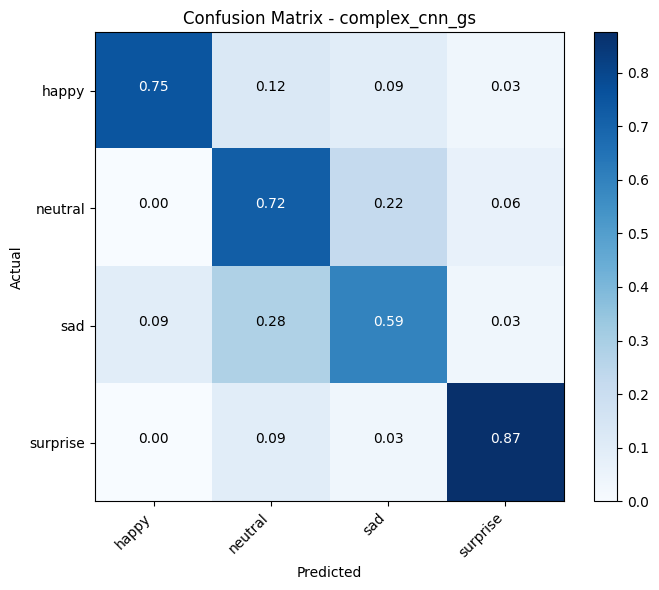


EVALUATION RESULTS - COMPLEX CUSTOM GS CNN (5 BLOCKS)
Test accuracy: 0.734
Test macro F1: 0.737
Test weighted F1: 0.737

✓ Complex Custom GS CNN Training and Evaluation Complete!


In [17]:
# =============================================================================
# COMPLEX CUSTOM GS CNN EVALUATION PIPELINE
# =============================================================================

print("\n" + "=" * 70)
print("PHASE 2: EVALUATION COMPLEX CUSTOM GS CNN")
print("=" * 70)

# Evaluate on test set
complex_test_metrics_gs = evaluate_model(
    model=complex_trained_gs,
    test_dataset=test_gen_complex_gs,  # Using grayscale data
    model_name="complex_cnn_gs",
    run_dir=run_dir_complex_gs,
    class_labels=CLASS_LABELS
)

# Show evaluation results
print_evaluation_summary(complex_test_metrics_gs, "Complex Custom GS CNN (5 Blocks)")

# Create summary row for model comparison
complex_summary_gs = create_model_summary(
    complex_trained_gs, 
    complex_history_gs, 
    complex_test_metrics_gs, 
    "Complex-GS-CNN-5Blocks",
    training_time=train_time_gs
)
append_summary_row(complex_summary_gs)

# Save hyperparameters
save_metrics(
    {
        "name": "Complex Custom GS CNN (5 Blocks)",
        "architecture": "Custom GS CNN",
        "channels": [64, 128, 512, 512, 128],
        "convs_per_block": 2,
        "dropout_head": 0.3,
        "activation": "leakyrelu",
        "l2_reg": 0.001,
        "lr": 0.0001,
        "img_size": list(IMAGE_SHAPE_COMPLEX_GS),
        "batch_size": BATCH_SIZE_COMPLEX,
        "color_mode": COLOR_MODE_COMPLEX,
        "augment": AUGMENT_COMPLEX,
        "epochs": COMPLEX_EPOCHS,
        "total_layers": "5 blocks × 3 conv = 15 conv layers",
        "data_type": "grayscale"
    },
    run_dir_complex_gs / "hparams.json"
)

print("\n" + "=" * 70)
print("✓ Complex Custom GS CNN Training and Evaluation Complete!")
print("=" * 70)

## RGB

In [18]:
# =============================================================================
# DATA LOADERS FOR COMPLEX CUSTOM RGB CNN (WITH AUGMENTATION)
# =============================================================================

print("=" * 70)
print("CREATING DATA LOADERS FOR COMPLEX CUSTOM RGB CNN")
print("=" * 70)

# Configuration for Complex Custom RGB CNN
IMG_SIZE_COMPLEX = (48, 48)
IMAGE_SHAPE_COMPLEX_RGB = (*IMG_SIZE_COMPLEX, 3) # 3 channels
BATCH_SIZE_COMPLEX = 64
COLOR_MODE_COMPLEX = "rgb"
AUGMENT_COMPLEX = True  # Enable augmentation for better generalization


print(f"Image size: {IMG_SIZE_COMPLEX}")
print(f"Batch size: {BATCH_SIZE_COMPLEX}")
print(f"Color mode: {COLOR_MODE_COMPLEX}")
print(f"Augmentation: {AUGMENT_COMPLEX}")

# Create data loaders for Complex Custom RGB CNN
train_gen_complex_rgb, val_gen_complex_rgb, test_gen_complex_rgb = make_generators(
    train_dir=TRAIN_DATA_DIR,
    val_dir=VALIDATION_DATA_DIR,
    test_dir=TEST_DATA_DIR,
    img_size=IMG_SIZE_COMPLEX,
    color_mode=COLOR_MODE_COMPLEX,
    batch_size=BATCH_SIZE_COMPLEX,
    augment=AUGMENT_COMPLEX
)

# Sanity check for Complex Custom RGB CNN data
print("\n" + "=" * 70)
print("SANITY CHECK - COMPLEX CUSTOM RGB CNN DATA")
print("=" * 70)

# Get a sample batch
for xb, yb in train_gen_complex_rgb.take(1):
    break

print(f"Train batch shape: {xb.shape}")
print(f"Labels shape: {yb.shape}")
print(f"Image dtype: {xb.dtype}")
print(f"Label dtype: {yb.dtype}")
print(f"Image range: [{tf.reduce_min(xb):.3f}, {tf.reduce_max(xb):.3f}]")
print(f"Unique labels: {tf.unique(yb)[0].numpy()}")

# Check if augmentation is working
print(f"\nAugmentation enabled: {AUGMENT_COMPLEX}")
if AUGMENT_COMPLEX:
    print("✓ Data augmentation is active - images will be randomly transformed during training")
else:
    print("⚠ Data augmentation is disabled")

print("=" * 70)
print("✓ Complex Custom RGB CNN data loaders created successfully")
print("=" * 70)

CREATING DATA LOADERS FOR COMPLEX CUSTOM RGB CNN
Image size: (48, 48)
Batch size: 64
Color mode: rgb
Augmentation: True
--------------------------------------------------
Train data:
Found 15109 files belonging to 4 classes.
Validation data:
Found 4977 files belonging to 4 classes.
Test data:
Found 128 files belonging to 4 classes.

SANITY CHECK - COMPLEX CUSTOM RGB CNN DATA
Train batch shape: (64, 48, 48, 3)
Labels shape: (64,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>
Image range: [0.000, 1.000]
Unique labels: [1 0 2 3]

Augmentation enabled: True
✓ Data augmentation is active - images will be randomly transformed during training
✓ Complex Custom RGB CNN data loaders created successfully


In [19]:
# =============================================================================
# USE THE SAME FIXED CLASS WEIGHTS FOR RGB MODEL
# =============================================================================

print("=" * 70)
print("USING FIXED CLASS WEIGHTS FOR RGB MODEL (SAME AS GRAYSCALE)")
print("=" * 70)

# Use the SAME FIXED class weights - no recomputation needed!
# This ensures consistent class weight mapping across all experiments
print_dict_table(CLASS_WEIGHTS, title="Class weights (FIXED)", val_header="Value", show_percent=False, value_decimals=3)

print("=" * 70)
print("COMPLEX CUSTOM RGB CNN - 5 BLOCKS ARCHITECTURE")
print("=" * 70)
print("✓ Using RGB mode")
print("✓ 5 convolutional blocks for maximum capacity")
print("✓ Heavy regularization to prevent overfitting")
print("=" * 70)

# Create complex RGB CNN with 5 blocks
cnn_complex_rgb = build_cnn(
    input_shape=IMAGE_SHAPE_COMPLEX_RGB,  # (48, 48, 3) - rgb
    num_classes=NUM_CLASSES,
    channels=(64, 128, 512, 512, 128),  
    convs_per_block=2,                   
    dropout_head=0.3,                    
    activation="leakyrelu",
    l2_reg=0.001,
    lr=0.0001                            
)

print("\n" + "=" * 70)
print("COMPLEX RGB CNN MODEL SUMMARY")
print("=" * 70)
cnn_complex_rgb.summary()

total_params = cnn_complex_rgb.count_params()
print(f"\n" + "=" * 70)
print("COMPLEX RGB CNN STATISTICS")
print("=" * 70)
print(f"Total parameters: {total_params:,}")
print(f"Model size: ~{total_params * 4 / 1024:.1f} KB")
print(f"Architecture: 5 blocks × 3 conv layers = 15 conv layers")
print("=" * 70)

USING FIXED CLASS WEIGHTS FOR RGB MODEL (SAME AS GRAYSCALE)
Class weights (FIXED)
Class  Value
-----  -----
0      0.950
1      0.950
2      0.949
3      1.190
-----  -----
TOTAL  4.039
COMPLEX CUSTOM RGB CNN - 5 BLOCKS ARCHITECTURE
✓ Using RGB mode
✓ 5 convolutional blocks for maximum capacity
✓ Heavy regularization to prevent overfitting

COMPLEX RGB CNN MODEL SUMMARY
Model: "emotion_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 48, 48, 3)]       0         
                                                                 
 conv_1_1 (Conv2D)           (None, 48, 48, 64)        1792      
                                                                 
 bn_1_1 (BatchNormalization  (None, 48, 48, 64)        256       
 )                                                               
                                                                 
 leaky_re_lu

COMPLEX CUSTOM RGB CNN TRAINING CONFIGURATION
Maximum epochs: 50
Batch size: 64
Image size: (48, 48)
Data augmentation: True
Class weights: Enabled
Architecture: 5 blocks × 3 conv layers = 15 conv layers
Parameters: 8,678,724

PHASE 1: TRAINING COMPLEX CUSTOM RGB CNN
Starting training for complex_cnn_rgb...
Training started at: 2025-10-12 16:43:56
Epoch 1/50
237/237 [==============================] - ETA: 0s - loss: 6.3446 - sparse_categorical_accuracy: 0.5136
Epoch 1: val_sparse_categorical_accuracy improved from -inf to 0.58007, saving model to ../../models/best_complex_cnn_rgb.keras
237/237 [==============================] - 14s 43ms/step - loss: 6.3446 - sparse_categorical_accuracy: 0.5136 - val_loss: 6.0725 - val_sparse_categorical_accuracy: 0.5801 - lr: 1.0000e-04
Epoch 2/50
237/237 [==============================] - ETA: 0s - loss: 5.7022 - sparse_categorical_accuracy: 0.6526
Epoch 2: val_sparse_categorical_accuracy improved from 0.58007 to 0.67872, saving model to ../../models/

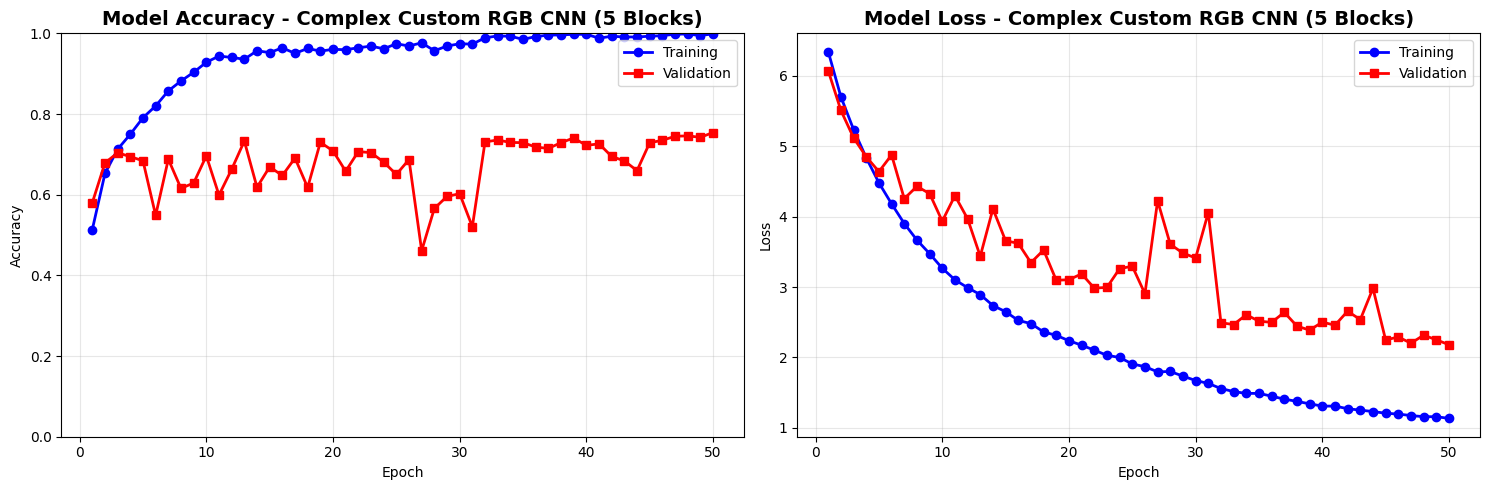

In [20]:
# =============================================================================
# COMPLEX CUSTOM RGB CNN TRAINING PIPELINE
# =============================================================================

# Training configuration for Complex RGB CNN
COMPLEX_EPOCHS = 50  # More epochs for complex model

# Callbacks for Complex RGB CNN
callbacks_complex = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,  # More patience for complex model
        restore_best_weights=True,
        verbose=1
    ),
    
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / "best_complex_cnn_rgb.keras"),
        monitor=VAL_METRIC_NAME,
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    keras.callbacks.TensorBoard(
        log_dir=RUNS_DIR / "tensorboard" / "complex_cnn_rgb",
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch'
    )
]

print("=" * 70)
print("COMPLEX CUSTOM RGB CNN TRAINING CONFIGURATION")
print("=" * 70)
print(f"Maximum epochs: {COMPLEX_EPOCHS}")
print(f"Batch size: {BATCH_SIZE_COMPLEX}")
print(f"Image size: {IMG_SIZE_COMPLEX}")
print(f"Data augmentation: {AUGMENT_COMPLEX}")
print(f"Class weights: Enabled")
print(f"Architecture: 5 blocks × 3 conv layers = 15 conv layers")
print(f"Parameters: {cnn_complex_rgb.count_params():,}")
print("=" * 70)

# Create run directory
run_dir_complex_rgb = make_run_dir("complex_cnn_5blocks_rgb")

# Train Complex RGB CNN model
print("\n" + "=" * 70)
print("PHASE 1: TRAINING COMPLEX CUSTOM RGB CNN")
print("=" * 70)

complex_trained_rgb, complex_history_rgb, train_time_rgb = train_model(
    model=cnn_complex_rgb,
    train_dataset=train_gen_complex_rgb, 
    val_dataset=val_gen_complex_rgb,      
    model_name="complex_cnn_rgb",
    run_dir=run_dir_complex_rgb,
    class_labels=CLASS_LABELS,
    epochs=COMPLEX_EPOCHS,
    callbacks=callbacks_complex,
    class_weights=CLASS_WEIGHTS
)

# Show training results
print_training_summary(complex_history_rgb, "Complex Custom RGB CNN (5 Blocks)")

# Plot training history
plot_training_history(
    complex_history_rgb, 
    "Complex Custom RGB CNN (5 Blocks)", 
    save_path=run_dir_complex_rgb / "training_history.png"
)


PHASE 2: EVALUATION COMPLEX CUSTOM RGB CNN
Starting evaluation for complex_cnn_rgb...


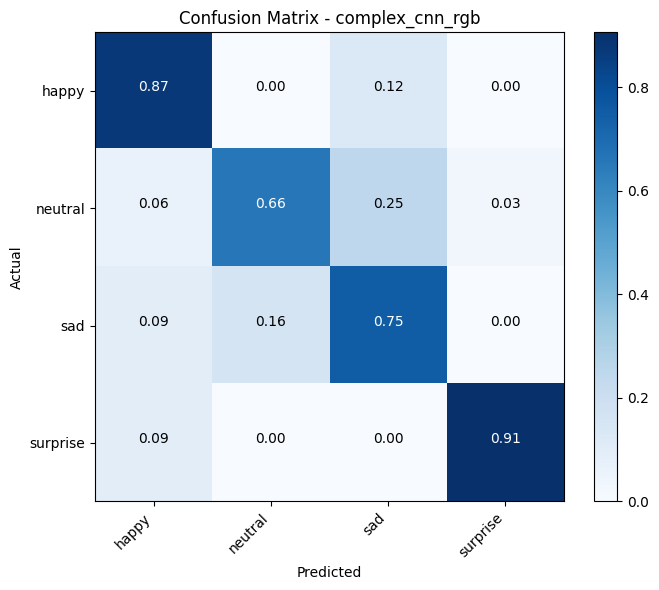


EVALUATION RESULTS - COMPLEX CUSTOM RGB CNN (5 BLOCKS)
Test accuracy: 0.797
Test macro F1: 0.797
Test weighted F1: 0.797

✓ Complex Custom RGB CNN Training and Evaluation Complete!


In [21]:
# =============================================================================
# COMPLEX CUSTOM RGB CNN EVALUATION PIPELINE
# =============================================================================

print("\n" + "=" * 70)
print("PHASE 2: EVALUATION COMPLEX CUSTOM RGB CNN")
print("=" * 70)

# Evaluate on test set
complex_test_metrics_rgb = evaluate_model(
    model=complex_trained_rgb,
    test_dataset=test_gen_complex_rgb,  # Using rgb data
    model_name="complex_cnn_rgb",
    run_dir=run_dir_complex_rgb,
    class_labels=CLASS_LABELS
)

# Show evaluation results
print_evaluation_summary(complex_test_metrics_rgb, "Complex Custom RGB CNN (5 Blocks)")

# Create summary row for model comparison
complex_summary_rgb = create_model_summary(
    complex_trained_rgb, 
    complex_history_rgb, 
    complex_test_metrics_rgb, 
    "Complex-RGB-CNN-5Blocks",
    training_time=train_time_rgb
)
append_summary_row(complex_summary_rgb)

# Save hyperparameters
save_metrics(
    {
        "name": "Complex Custom RGB CNN (5 Blocks)",
        "architecture": "Custom RGB CNN",
        "channels": [64, 128, 512, 512, 128],
        "convs_per_block": 2,
        "dropout_head": 0.3,
        "activation": "leakyrelu",
        "l2_reg": 0.001,
        "lr": 0.0001,
        "img_size": list(IMAGE_SHAPE_COMPLEX_RGB),
        "batch_size": BATCH_SIZE_COMPLEX,
        "color_mode": COLOR_MODE_COMPLEX,
        "augment": AUGMENT_COMPLEX,
        "epochs": COMPLEX_EPOCHS,
        "total_layers": "5 blocks × 3 conv = 15 conv layers",
        "data_type": "rgb"
    },
    run_dir_complex_rgb / "hparams.json"
)

print("\n" + "=" * 70)
print("✓ Complex Custom RGB CNN Training and Evaluation Complete!")
print("=" * 70)

In [22]:
# =============================================================================
# FULL TRAINING RUN - COMPLETION
# =============================================================================

FULL_RUN_END_TIME = time.time()
FULL_RUN_END_STR = time.strftime("%Y-%m-%d %H:%M:%S")
FULL_RUN_DURATION = FULL_RUN_END_TIME - FULL_RUN_START_TIME

print("\n" + "=" * 100)
print("FULL TRAINING RUN COMPLETED")
print("=" * 100)
print(f"Started: {FULL_RUN_START_STR}")
print(f"Ended: {FULL_RUN_END_STR}")
print(f"Total Duration: {FULL_RUN_DURATION/3600:.2f} hours ({FULL_RUN_DURATION/60:.1f} minutes)")
print("")
print("All models trained and evaluated successfully!")
print("Check REPORTS_DIR for final comparison and visualizations.")
print("=" * 100)

# Save overall run statistics
save_metrics(
    {
        "full_run_start": FULL_RUN_START_STR,
        "full_run_end": FULL_RUN_END_STR,
        "total_duration_hours": FULL_RUN_DURATION / 3600,
        "total_duration_minutes": FULL_RUN_DURATION / 60,
        "models_trained": 2,
        "random_seed": RANDOM_SEED
    },
    REPORTS_DIR / "full_run_stats.json"
)


FULL TRAINING RUN COMPLETED
Started: 2025-10-12 16:34:56
Ended: 2025-10-12 16:52:05
Total Duration: 0.29 hours (17.2 minutes)

All models trained and evaluated successfully!
Check REPORTS_DIR for final comparison and visualizations.
